<a href="https://colab.research.google.com/github/drawcodeboy/Cat_n_Dog_Classification/blob/main/cat_vs_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# 라이브러리 불러오기
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

In [38]:
# 데이터 불러오기
# Dataset 출처 (https://www.kaggle.com/datasets/tongpython/cat-and-dog)
# 구글 드라이브에 업로드하여 사용

train_path = '/content/drive/MyDrive/training_set/training_set'
test_path = '/content/drive/MyDrive/test_set/test_set'

#os.listdir()
>* 해당 경로에 몇 개의 파일 또는 디렉터리가 존재하는지 확인
#os.endswith()
>* 특정 확장자를 지정(문자열)을 지정하여 어떤 파일 특정 확장자로 끝나는지 확인

In [25]:
print(os.listdir(train_path))
print(os.listdir(test_path))

['dogs', 'cats']
['dogs', 'cats']


# plt.imread()


(-0.5, 497.5, 414.5, -0.5)

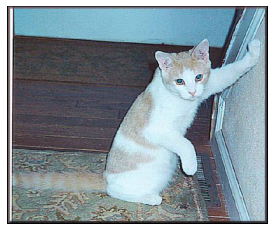

In [40]:
# test_set에서 그림 불러오기
plt.imshow(plt.imread('/content/drive/MyDrive/test_set/test_set/cats/cat.4001.jpg'))
plt.axis('off')

# os.walk()
>* 하위의 폴더들을 for문으로 탐색할 수 있게 한다. 인자로 전달된 path에 대해 3개의 값이 있는 tuple을 넘겨준다.
>* first(root): dir과 files가 있는 path
>* second(dirs): root 아래에 있는 폴더들
>* third(files): root 아래에 있는 파일들
# os.path.join()
>* 인수에 전달된 2개의 문자열을 결합하여, 1개의 경로로 할 수있다.

https://codechacha.com/ko/python-walk-files/

In [36]:
test_list = [] # test_set의 파일 경로들을 담은 리스트

for dirname, _, filenames in os.walk(test_path):
    #print(filenames)
    for filename in filenames:
        #print(filename)
        test_count = os.path.join(dirname, filename)
        test_list.append(test_count)

In [37]:
train_list = []

for dirname, _, filenames in os.walk(train_path):
    for filename in filenames:
        train_count = os.path.join(dirname, filename)
        train_list.append(train_count)

(-0.5, 499.5, 479.5, -0.5)

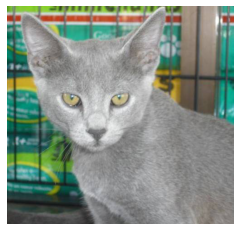

In [42]:
plt.imshow(plt.imread(train_list[0]))
plt.axis('off')

# PIL(pillow) 모듈 : 이미지 처리 모듈
>* Image 패키지
>* Image.open(path)를 통해 그림을 가져와서 numpy로 바꿀 수 있다.
>* https://ddolcat.tistory.com/690

(480, 500, 3)
(374, 500, 3)
(335, 344, 3)
(273, 500, 3)
(200, 296, 3)
(374, 500, 3)
(400, 353, 3)
(375, 499, 3)
(333, 500, 3)
(374, 500, 3)


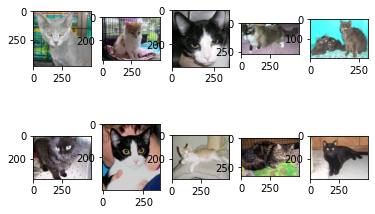

In [55]:
# 이미지 10개 정도 train_set에서 순차적으로 골라서 shape 확인
from PIL import Image

fig, ax = plt.subplots(2, 5)

for i, jpg_path in enumerate(train_list):
    if(i == 10):
        break
    img = Image.open(jpg_path)
    ax[i // 5][i % 5].imshow(img)
    img_array = np.array(img)
    print(img_array.shape)

plt.show()

# 이미지마다 shape가 각각 다 다르다 -> 같게 해줄 필요가 있다.

# 할 일
>* Image Size 통일
>* Dog, Cat 분리
>* CNN Modeling